In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic, utils, binary_utils, table_utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from spisea.imf import multiplicity

# PopSyCLE with Multiples

This is an example of running PopSyCLE with binary and triple systems

In additional to the usual python/astropy things, you'll need to install Galaxia, SPISEA, BAGLE, and PopSyCLE.
For SPISEA, it goes faster once you've made isochrones.
Same goes from PopSyCLE with the initial-final cluster mass ratio file.

# Galaxia

This is where you generate the stellar model and set the survey direction and area.

Galaxia requires a text file containing the parameters you want for the model,
following the format given in the Galaxia example. That file can either be 
generated by hand, or with the `write_galaxia_params` function. 
This is unchanged from the singles-only case

To create the file `example_galaxia_params.txt`, run:


In [2]:
synthetic.write_galaxia_params(output_root = 'example',
                               longitude = 1.25,
                               latitude = -2.65,
                               area = 0.001)

** Generating example_galaxia_params.txt **
-- outputFile example
-- outputDir ./
-- photoSys UBV
-- magcolorNames V,B-V
-- appMagLimits[0] -1000
-- appMagLimits[1] 1000
-- absMagLimits[0] -1000
-- absMagLimits[1] 1000
-- colorLimits[0] -1000
-- colorLimits[1] 1000
-- geometryOption 1
-- longitude 1.250000
-- latitude -2.650000
-- surveyArea 0.00100
-- fSample 1
-- popID -1
-- warpFlareOn 1
-- seed 31
-- r_max 30
-- starType 0
-- photoError 0



Then create the stellar model, 
by running `galaxia -r example_galaxia_params.txt` on the command line. 
PopSyCLE can also combine these two steps by executing:


In [ ]:
synthetic.run_galaxia(output_root = 'example',
                      longitude = 1.25,
                      latitude = -2.65,
                      area = 0.001,
                      galaxia_galaxy_model_filename= '/g/lu/code/galaxia/docs/galaxyModelParams_PopSyCLEv3.txt')

** Generating example_galaxia_params.txt **
-- outputFile example
-- outputDir ./
-- photoSys UBV
-- magcolorNames V,B-V
-- appMagLimits[0] -1000
-- appMagLimits[1] 1000
-- absMagLimits[0] -1000
-- absMagLimits[1] 1000
-- colorLimits[0] -1000
-- colorLimits[1] 1000
-- geometryOption 1
-- longitude 1.250000
-- latitude -2.650000
-- surveyArea 0.00100
-- fSample 1
-- popID -1
-- warpFlareOn 1
-- seed 57
-- r_max 30
-- starType 0
-- photoError 0
** Executing Galaxia with example_galaxia_params.txt and /g/lu/code/galaxia/docs/galaxyModelParams_PopSyCLEv3.txt **


 
The results should look like this:



CODEDATAPATH=/u/casey_lam/scratch/GalaxiaData/

Reading Parameter file-             example_galaxia_params.txt
___

outputFile               example                 
outputDir                ./                      
photoSys                 UBV                     
magcolorNames            V,B-V                   
appMagLimits[0]          -1000                   
appMagLimits[1]          1000                    
absMagLimits[0]          -1000                   
absMagLimits[1]          1000                    
colorLimits[0]           -1000                   
colorLimits[1]           1000                    
geometryOption           1                       
longitude                1.25                    
latitude                 -2.65                   
surveyArea               0.001                   
fSample                  1                       
popID                    -1                      
warpFlareOn              1                       
seed                     12                      
r_max                    20                      
starType                 0                       
photoError               0                       
___
Reading tabulated values from file- /u/casey_lam/scratch/GalaxiaData/Model/vcirc.dat
Using geometry:                     Patch at l ,b : (1.25 -2.65) d_theta=0.0178412
Reading Isochrones from dir-        /u/casey_lam/scratch/GalaxiaData/Isochrones/padova/UBV
Isochrone Grid Size:                (Age bins=182,Feh bins=34,Alpha bins=1)
Time Isocrhone Reading              2.73553     
Generating populations................
___
Thin Disk,ID=0:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_0_E1.ebf
Time Tree generation/reading =      1.34589     
Completed % <0..10..20..30..40..50..60..70..80..90..>
Stars spawned =                     15          
Time Spawning=                      0.519746    
___
Thin Disk,ID=1:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_1_E1.ebf
Time Tree generation/reading =      0.894184    
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     785         
Time Spawning=                      3.01123     
___
Thin Disk,ID=2:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_2_E1.ebf
Time Tree generation/reading =      1.21969     
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     2304        
Time Spawning=                      2.31239     
___
Thin Disk,ID=3:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_3_E1.ebf
Time Tree generation/reading =      1.12221     
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     3299        
Time Spawning=                      2.63636     
___
Thin Disk,ID=4:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_4_E1.ebf
Time Tree generation/reading =      1.12869     
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     9040        
Time Spawning=                      5.16435     
___
Thin Disk,ID=5:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_5_E1.ebf
Time Tree generation/reading =      0.924357    
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     9983        
Time Spawning=                      5.99943     
___
Thin Disk,ID=6:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_6_E1.ebf
Time Tree generation/reading =      1.03473     
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     11927       
Time Spawning=                      5.80737     
___
ThickDisk:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_7_E0.ebf
Time Tree generation/reading =      1.00016     
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     6561        
Time Spawning=                      1.83702     
___
Spheroid:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_8_E0.ebf
Time Tree generation/reading =      0.320754    
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     589         
Time Spawning=                      0.693446    
___
Bulge:
Reading tree from file-             /u/casey_lam/scratch/GalaxiaData/BHTree-2.2/bhtree_with_wf/bhtree_9_E0.ebf
Time Tree generation/reading =      1.0575      
Completed % <0..9..19..29..39..49..59..69..79..89..99..>
Stars spawned =                     620676      
Time Spawning=                      28.1113     
___
Total stars written                 665179                  
File written-                       .//example.ebf
Calulating magnitudes................
Reading Isochrones from dir-        /u/casey_lam/scratch/GalaxiaData/Isochrones/padova/UBV
Isochrone Grid Size:                (Age bins=182,Feh bins=34,Alpha bins=1)
Time Isocrhone Reading              2.67512     
Calulating Extinction................
Time for extinction calculation     0.876306    
Total Time=                         73.89 


# Population Synthesis

The stellar model now needs compact objects, which we inject with SPISEA. 
This produces an .h5 file with both stars and compact objects, sorted by latitude and longitude.
Here you can set the black hole and neutron star kick speed means, as well as the SPISEA IFMR object used to produce the compact objects.
We set a multiplicity object to include multiple systems. We specify the CSF_max = 2 to limit the maximum number of companions to 2 (i.e. triples).
This also has the option of being parallelizable.

In [4]:
synthetic.perform_pop_syn(ebf_file = 'example.ebf', 
                          output_root = 'example',
                          iso_dir = '/g/lu/models/PopSyCLE_isochrones',
                          IFMR = 'SukhboldN20',
                          bin_edges_number = None, 
                          BH_kick_speed_mean = 100, 
                          NS_kick_speed_mean = 350,
                          multiplicity=multiplicity.MultiplicityResolvedDK(CSF_max = 2, companion_max = True),
                          n_proc=1,
                          overwrite=True)

******************** Starting popid 0
********** Starting log age bin 6.4
***** Starting metallicity bin  -1.39
***** Starting metallicity bin  -0.89
***** Starting metallicity bin  -0.25
***** Starting metallicity bin  0.3
********** Starting log age bin 6.3
***** Starting metallicity bin  -1.39
***** Starting metallicity bin  -0.89
***** Starting metallicity bin  -0.25
***** Starting metallicity bin  0.3
** Starting sub-bin  0 with 3 stars in bin
********** Starting log age bin 7.0
***** Starting metallicity bin  -1.39
***** Starting metallicity bin  -0.89
***** Starting metallicity bin  -0.25
** Starting sub-bin  0 with 2 stars in bin
***** Starting metallicity bin  0.3
** Starting sub-bin  0 with 3 stars in bin
********** Starting log age bin 7.7
***** Starting metallicity bin  -1.39
***** Starting metallicity bin  -0.89
***** Starting metallicity bin  -0.25
** Starting sub-bin  0 with 1 stars in bin
***** Starting metallicity bin  0.3
** Starting sub-bin  0 with 7 stars in bin
***

/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


******************** Starting popid 6
********** Starting log age bin 9.8
***** Starting metallicity bin  -1.39
***** Starting metallicity bin  -0.89
** Starting sub-bin  0 with 116 stars in bin
***** Starting metallicity bin  -0.25
** Starting sub-bin  0 with 1005 stars in bin
***** Starting metallicity bin  0.3
** Starting sub-bin  0 with 1735 stars in bin


/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


********** Starting log age bin 9.9
***** Starting metallicity bin  -1.39
** Starting sub-bin  0 with 6 stars in bin
***** Starting metallicity bin  -0.89
** Starting sub-bin  0 with 168 stars in bin
***** Starting metallicity bin  -0.25
** Starting sub-bin  0 with 1280 stars in bin
***** Starting metallicity bin  0.3
** Starting sub-bin  0 with 1641 stars in bin


...

********** Starting log age bin 10.0
***** Starting metallicity bin  -1.39
** Starting sub-bin  0 with 2 stars in bin
***** Starting metallicity bin  -0.89
** Starting sub-bin  0 with 195 stars in bin
***** Starting metallicity bin  -0.25
** Starting sub-bin  0 with 1307 stars in bin
***** Starting metallicity bin  0.3
** Starting sub-bin  0 with 1304 stars in bin


/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


******************** Starting popid 7
********** Starting log age bin 9.9
***** Starting metallicity bin  -1.39
** Starting sub-bin  0 with 299 stars in bin
***** Starting metallicity bin  -0.89
** Starting sub-bin  0 with 5199 stars in bin
***** Starting metallicity bin  -0.25
** Starting sub-bin  0 with 1247 stars in bin
***** Starting metallicity bin  0.3
** Starting sub-bin  0 with 33 stars in bin
******************** Starting popid 8
********** Starting log age bin 10.0
***** Starting metallicity bin  -1.39
** Starting sub-bin  0 with 465 stars in bin
***** Starting metallicity bin  -0.89
** Starting sub-bin  0 with 83 stars in bin
***** Starting metallicity bin  -0.25
** Starting sub-bin  0 with 3 stars in bin
***** Starting metallicity bin  0.3
******************** Starting popid 9
********** Starting log age bin 9.9
***** Starting metallicity bin  -1.39
** Starting sub-bin  0 with 202 stars in bin
***** Starting metallicity bin  -0.89
** Starting sub-bin  0 with 33557 stars in 

/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/mambafo

No version information found for evolution model MISTv1.
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
No version information found for evolution model MISTv1.
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
No version information found for evolution model MISTv1.
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
No version information found for evolution model MISTv1.
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
No version information found for evolution model MISTv1.
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
No version information found for evolution model MISTv1.
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact objects
Remove low mass stars, keep compact object

# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
To include multiples you must specify the hdf5 companion file.
This also has the option of being parallelizable.

In [5]:
synthetic.calc_events(hdf5_file = 'example.h5',
                      hdf5_file_comp = 'example_companions.h5',
                      output_root2 = 'example', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = False, 
                      n_proc = 1)

Working on loop ll, bb =  0 0
Candidate events detected:  570
calc_events runtime : 34.785615 s


# Photometry

In refine_events you specify a photometric band or bands for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.
To include multiples you must specify the hdf5 companion file.

In [6]:
synthetic.refine_events(input_root = 'example',
                        hdf5_file_comp = 'example_companions.h5',
                        filter_dict={'ubv':['I']},
                        red_law = 'Damineli16', 
                        overwrite = False, 
                        output_file = 'default')

Original candidate events:  504
Candidate events in survey window:  113
On square l0b0
On square l0b1
On square l1b0
On square l1b1
refine_events runtime : 4.612090 s


# Generating Binary Lightcurves

In this step we generate binary lightcurves (PSBL, BSPL, BSBL) with BAGLE models. In higher order system cases, we will simulate all pairs of primary-companion and use the lightcurve with the highest bump magnitude (see documentation for details).

In [2]:
synthetic.refine_binary_events('example_refined_events_ubv_I_Damineli16.fits', 
                               'example_refined_events_ubv_I_Damineli16_companions.fits', 
                               filter_dict = {'ubv':['I']},
                               overwrite = True,
                               n_proc=1,
                               output_file = 'default', 
                               save_phot = True, 
                               phot_dir = 'example_bin_phot')

refine_binary_events runtime : 39.045931 s


# Things you can do with PopSyCLE

First, read in the tables, and print out a list of all the possible keys. The event table has a row for each event.

In [3]:
t = Table.read('example_refined_events_ubv_I_Damineli16_rb.fits')
print(t.colnames)

['obj_id_L', 'obj_id_S', 'age_L', 'popid_L', 'zams_mass_L', 'mass_L', 'systemMass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'isMultiple_L', 'N_companions_L', 'rem_id_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'ubv_U_L', 'ubv_I_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'vr_L', 'mu_b_L', 'mu_lcosb_L', 'sep_L', 'age_S', 'popid_S', 'zams_mass_S', 'mass_S', 'systemMass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'isMultiple_S', 'N_companions_S', 'rem_id_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'ubv_U_S', 'ubv_I_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'vr_S', 'mu_b_S', 'mu_lcosb_S', 'sep_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed', 'n_peaks', 'bin_delta_m', 'tE_sys', 'tE_primary

The companion table has a row for each companion.

In [4]:
t_companions = Table.read('example_refined_events_ubv_I_Damineli16_companions_rb.fits')
print(t_companions.colnames)

['system_idx', 'zams_mass', 'Teff', 'L', 'logg', 'isWR', 'mass', 'phase', 'metallicity', 'm_ubv_U', 'm_ubv_B', 'm_ubv_V', 'm_ubv_I', 'm_ubv_R', 'm_ubv_H', 'm_ubv_K', 'm_ubv_J', 'log_a', 'e', 'i', 'Omega', 'omega', 'prim_type', 'q', 'sep', 'P', 'obj_id_L', 'obj_id_S', 'alpha', 'phi_pi_E', 'phi', 'tp', 'companion_idx']


The multipeak table has a row for each peak besides the primary peak

In [5]:
t_peaks = Table.read('example_refined_events_ubv_I_Damineli16_companions_rb_multi_peaks.fits')
print(t_peaks.colnames)

['companion_idx', 'obj_id_L', 'obj_id_S', 'n_peaks', 't', 'tE', 'delta_m', 'ratio']


The lightcurve table has a row for each lightcurve generated. Whether it was used or not is specified in the 'used_lightcurve' column

In [6]:
t_lightcurves = Table.read('example_refined_events_ubv_I_Damineli16_rb_lightcurves.fits')
print(t_lightcurves.colnames)

['obj_id_L', 'obj_id_S', 'companion_id_L', 'companion_id_S', 'class', 'n_peaks', 'bin_delta_m', 'tE_sys', 'tE_primary', 'primary_t', 'avg_t', 'std_t', 'asymmetry', 'used_lightcurve']


## Make observational cuts

First add an additional column with the number of observable peaks for binary events, then make
cuts based on the baseline magnitude, u0, and delta_m. You can make additional cuts, beyond this function if desired. Note these are standard observational cuts we make, but the patch is too small to leave any events after cuts.

In [7]:
t = binary_utils.add_observable_peaks_column(t, 
                                             t_companions, 
                                             t_peaks, 
                                             t_lightcurves, 
                                             delta_m_cutoff = 0.1, 
                                             delta_m_cutoff_secondary = 0.02,
                                             match_by_field = False)

In [8]:
t_cut, t_cut_one_peak, t_multiples_cut_multi_peak = table_utils.cut_Mruns(t, 
                                                                          t_companions, 
                                                                          t_peaks, 
                                                                          min_mag = 22, 
                                                                          delta_m_cut = 0.1, 
                                                                          u0_cut = 2, 
                                                                          photometric_system='ubv',
                                                                          filter_name = 'I',
                                                                          S_LSN = 'S')

## Figure out how many events due to BH, NS, WD, star

In [9]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 3
Number of NSs: 5
Number of WDs: 55
Number of stars: 50


## Figure out how many events contain a binary or triple system

In [10]:
pspl = np.where((t['isMultiple_L'] == 0) & (t['isMultiple_S'] == 0))[0]
bspl = np.where((t['N_companions_L'] == 0) & (t['N_companions_S'] == 1))[0]
psbl = np.where((t['N_companions_L'] == 1) & (t['N_companions_S'] == 0))[0]
bsbl = np.where((t['N_companions_L'] == 1) & (t['N_companions_S'] == 1))[0]
tspl = np.where((t['N_companions_L'] == 0) & (t['N_companions_S'] == 2))[0]
pstl = np.where((t['N_companions_L'] == 2) & (t['N_companions_S'] == 0))[0]
bstl = np.where((t['N_companions_L'] == 1) & (t['N_companions_S'] == 2))[0]
tsbl = np.where((t['N_companions_L'] == 2) & (t['N_companions_S'] == 1))[0]
tstl = np.where((t['N_companions_L'] == 2) & (t['N_companions_S'] == 2))[0]

print('Number of PSPL: ' + str(len(pspl)))
print('Number of BSPL: ' + str(len(bspl)))
print('Number of PSBL: ' + str(len(psbl)))
print('Number of BSBL: ' + str(len(bsbl)))
print('Number of TSPL: ' + str(len(tspl)))
print('Number of PSTL: ' + str(len(pstl)))
print('Number of BSTL: ' + str(len(bstl)))
print('Number of TSBL: ' + str(len(tsbl)))
print('Number of TSTL: ' + str(len(tstl)))

Number of PSPL: 15
Number of BSPL: 14
Number of PSBL: 56
Number of BSBL: 8
Number of TSPL: 2
Number of PSTL: 15
Number of BSTL: 1
Number of TSBL: 1
Number of TSTL: 1


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

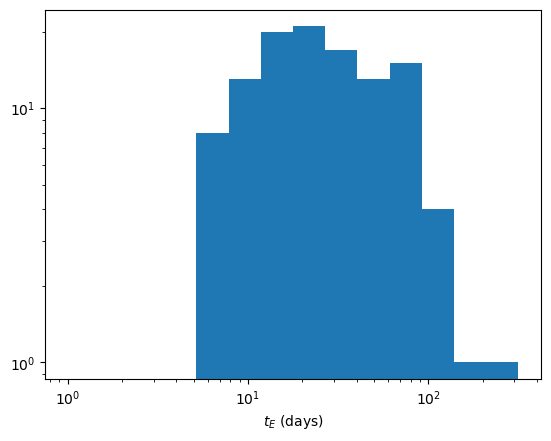

In [11]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

Text(0, 0.5, '$\\pi_E$')

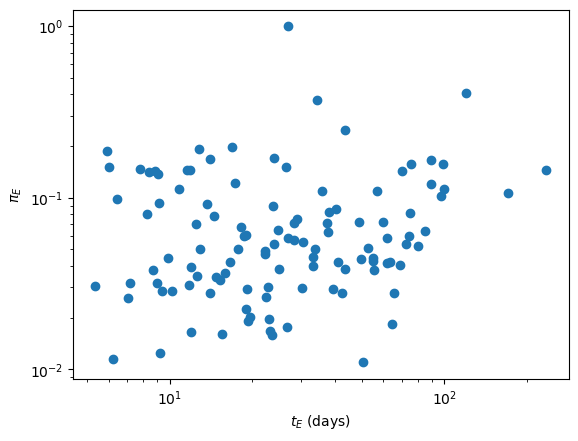

In [12]:
plt.scatter(t['t_E'], t['pi_E'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')

## dL vs dS

Text(0, 0.5, '$d_S$ (kpc)')

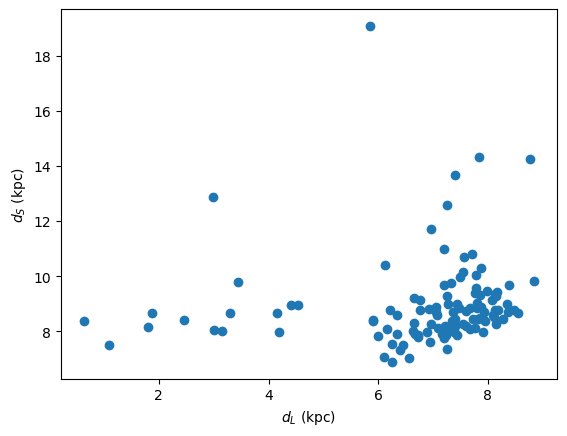

In [13]:
plt.scatter(t['rad_L'], t['rad_S'])
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')